## Pelabelan aplikasi Gopay

In [1]:
import pandas as pd

data = pd.read_csv("../../Preprocess/PreprocessGopay/DatasetPreprocessGopay/Tahap4Preprocessing.csv")
print(data.head())

                                         Review text  \
0                             baguss bangetzzzzzzzzz   
1  baik pelayan nan enya aman kalo transaksi ke m...   
2                                              bagus   
3  scan barcode terlalu bermasalah gagal teknis M...   
4  ini kok ga g ada konfir masi apa apa jol di po...   

                                          clean_text  \
0                             baguss bangetzzzzzzzzz   
1              baik pelayan enya aman kalo transaksi   
2                                              bagus   
3  scan barcode terlalu bermasalah gagal teknis m...   
4  konfir masi potong hedeuh jadi kapok nyimpen u...   

                                    normalisasi_text  \
0                              bagus bangetzzzzzzzzz   
1             baik pelayan enya aman kalau transaksi   
2                                              bagus   
3  scan barcode terlalu bermasalah gagal teknis m...   
4  konfir masih potong hedeuh jadi kapok menyi

In [2]:
# Cek apakah ada missing value di dalam dataset
data.isnull().sum()

Review text         0
clean_text          0
normalisasi_text    0
tokenize            0
stopword_removal    0
steming_data        0
dtype: int64

In [3]:
import pandas as pd
import csv

# Membaca kamus 
positive_path = "../../kamus/positive.tsv"
negative_path = "../../kamus/negative.tsv"

positive_data = pd.read_csv(positive_path, sep='\t', header=None, names=['word', 'score'], skiprows=1, encoding='utf-8')
negative_data = pd.read_csv(negative_path, sep='\t', header=None, names=['word', 'score'], skiprows=1, encoding='utf-8')

# Buat kamus dengan huruf kecil dan tanpa spasi
lexicon_positive = dict(zip(positive_data['word'].str.strip().str.lower(), positive_data['score'].astype(int)))
lexicon_negative = dict(zip(negative_data['word'].str.strip().str.lower(), negative_data['score'].astype(int)))

print(f"Kata positif: {len(lexicon_positive)} | Kata negatif: {len(lexicon_negative)}")

# Logika skoring kata, penentuan polaritas berdasarkan skor
def sentiment_analysis_lexicon(text):
    score = 0
    for word in str(text).lower().split():
        word = word.strip()
        if word in lexicon_positive:
            score += lexicon_positive[word]
        elif word in lexicon_negative:
            score -= abs(lexicon_negative[word])
    
    if score > 0:
        polarity = 'positive'
    elif score < 0:
        polarity = 'negative'
    else:
        polarity = 'neutral'

    return score, polarity

data[['score', 'label']] = data['steming_data'].apply(
    lambda x: pd.Series(sentiment_analysis_lexicon(x))
)

print(data[['steming_data', 'score', 'label']])


Kata positif: 3607 | Kata negatif: 6607
                                           steming_data  score     label
0                                 bagus bangetzzzzzzzzz      2  positive
1                             layan enya aman transaksi      6  positive
2                                                 bagus      2  positive
3          scan barcode masalah gagal teknis mulu payah     -6  negative
4     konfir potong hedeuh kapok simpan uang bahaya ...    -10  negative
...                                                 ...    ...       ...
9007                                 pasang force close      2  positive
9008  kecewa trsper gopay masuk sampi transparan ora...      5  positive
9009  respon tunggu menit respon transaksi hasil che...     14  positive
9010                                    moga gopay jaya      5  positive
9011                                 tolong gopay masuk      0   neutral

[9012 rows x 3 columns]


In [4]:
import os
folder_tujuan = 'DatasetPelabelanGopay' 

if not os.path.exists(folder_tujuan):
    os.makedirs(folder_tujuan)

path_output = os.path.join(folder_tujuan, 'Tahap5HasilPelabelan.csv')
data.to_csv(path_output, index=False, encoding='utf-8')
print(f"File berhasil disimpan di: {path_output}")
data.info()

File berhasil disimpan di: DatasetPelabelanGopay\Tahap5HasilPelabelan.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9012 entries, 0 to 9011
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Review text       9012 non-null   object
 1   clean_text        9012 non-null   object
 2   normalisasi_text  9012 non-null   object
 3   tokenize          9012 non-null   object
 4   stopword_removal  9012 non-null   object
 5   steming_data      9012 non-null   object
 6   score             9012 non-null   int64 
 7   label             9012 non-null   object
dtypes: int64(1), object(7)
memory usage: 563.4+ KB


## Pemodelan tanpa smote

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- 1. LOAD DATASET ---
file_path = "../../Pelabelan/PelabelanGopay/DatasetPelabelanGopay\Tahap5HasilPelabelan.csv"

try:
    data = pd.read_csv(file_path)
    print(f"[SUKSES] Data berhasil dimuat dari: {file_path}")
except FileNotFoundError:
    print(f"[ERROR] File tidak ditemukan di: {file_path}")
    print("Pastikan path file sudah benar.")
    exit() # Hentikan program jika file tidak ada

# --- 2. PERSIAPAN DATA (DATA PREPARATION) ---

# Pastikan kolom target ada
if 'steming_data' not in data.columns or 'Label' not in data.columns:
    print("[ERROR] Kolom 'steming_data' atau 'Label' tidak ditemukan.")
    print(f"Kolom yang tersedia: {list(data.columns)}")
    exit()

print(f"Jumlah data awal: {len(data)}")

# Konversi ke string (jaga-jaga jika ada angka) dan drop NaN
data['steming_data'] = data['steming_data'].astype(str)
data.dropna(subset=['steming_data', 'label'], inplace=True)

# Hapus data yang isinya hanya spasi kosong atau string kosong
data = data[data['steming_data'].str.strip() != '']
data = data[data['steming_data'] != 'nan'] # Hapus string "nan" literal jika ada

print(f"Jumlah data bersih: {len(data)}")

# Cek sebaran data (Penting untuk melihat imbalance)
print("\nSebaran Data per Label:")
print(data['label'].value_counts())

X_text = data['steming_data']
y = data['label']

# --- 3. EKSTRAKSI FITUR (TF-IDF) ---
print("\nMelakukan ekstraksi fitur TF-IDF...")
# max_features=5000 mengambil 5000 kata teratas berdasarkan frekuensi
tfidf = TfidfVectorizer(max_features=5000) 
X = tfidf.fit_transform(X_text)

print(f"Ukuran Matriks TF-IDF: {X.shape}") 

# --- 4. SPLIT DATA ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 5. PELATIHAN MODEL SVM ---
print("\nMelatih Model SVM...")

# PERBAIKAN: Tambahkan class_weight='balanced'
# Ini membantu jika jumlah data Positif jauh lebih banyak dari Negatif/Netral
svm_model = SVC(kernel='linear', class_weight='balanced', random_state=42) 
svm_model.fit(X_train, y_train)

print("Pelatihan selesai!")

# --- 6. EVALUASI MODEL ---
y_pred = svm_model.predict(X_test)
akurasi = accuracy_score(y_test, y_pred)

print(f"\n--- HASIL EVALUASI ---")
print(f"Akurasi Model: {akurasi * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


[SUKSES] Data berhasil dimuat dari: ../../Pelabelan/PelabelanGopay/DatasetPelabelanGopay\Tahap5HasilPelabelan.csv
[ERROR] Kolom 'steming_data' atau 'Label' tidak ditemukan.
Kolom yang tersedia: ['Review text', 'clean_text', 'normalisasi_text', 'tokenize', 'stopword_removal', 'steming_data', 'score', 'label']
Jumlah data awal: 9012
Jumlah data bersih: 9012

Sebaran Data per Label:
label
positive    6128
negative    1625
neutral     1259
Name: count, dtype: int64

Melakukan ekstraksi fitur TF-IDF...
Ukuran Matriks TF-IDF: (9012, 5000)

Melatih Model SVM...
Pelatihan selesai!

--- HASIL EVALUASI ---
Akurasi Model: 86.69%

Classification Report:
              precision    recall  f1-score   support

    negative       0.72      0.88      0.79       311
     neutral       0.66      0.84      0.74       269
    positive       0.98      0.87      0.92      1223

    accuracy                           0.87      1803
   macro avg       0.79      0.86      0.82      1803
weighted avg       0.89 

: 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB  # <--- IMPORT BARU
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- 1. LOAD DATASET ---
# Note: Python string path sebaiknya raw string (r"...") atau forward slash (/) semua
file_path = "../../Pelabelan/PelabelanGopay/DatasetPelabelanGopay\Tahap5HasilPelabelan.csv"
try:
    data = pd.read_csv(file_path)
    print(f"[SUKSES] Data berhasil dimuat dari: {file_path}")
except FileNotFoundError:
    print(f"[ERROR] File tidak ditemukan di: {file_path}")
    exit()

# --- 2. PERSIAPAN DATA (DATA PREPARATION) ---

# Perbaiki pengecekan kolom (gunakan 'label' huruf kecil sesuai error sebelumnya)
if 'steming_data' not in data.columns or 'label' not in data.columns:
    print("[ERROR] Kolom 'steming_data' atau 'label' tidak ditemukan.")
    print(f"Kolom yang tersedia: {list(data.columns)}")
    exit()

print(f"Jumlah data awal: {len(data)}")

# Konversi ke string & Bersihkan NaN
data['steming_data'] = data['steming_data'].astype(str)
data.dropna(subset=['steming_data', 'label'], inplace=True)

# Hapus data kosong/spasi saja
data = data[data['steming_data'].str.strip() != '']
data = data[data['steming_data'] != 'nan']

print(f"Jumlah data bersih: {len(data)}")

# Cek sebaran data
print("\nSebaran Data per Label:")
print(data['label'].value_counts())

X_text = data['steming_data']
y = data['label']

# --- 3. EKSTRAKSI FITUR (TF-IDF) ---
print("\nMelakukan ekstraksi fitur TF-IDF...")
tfidf = TfidfVectorizer(max_features=5000) 
X = tfidf.fit_transform(X_text)

print(f"Ukuran Matriks TF-IDF: {X.shape}") 

# --- 4. SPLIT DATA ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 5. PELATIHAN MODEL NAIVE BAYES ---
print("\nMelatih Model Naive Bayes (MultinomialNB)...")

# GANTI SVM DENGAN NAIVE BAYES DI SINI
nb_model = MultinomialNB() 
nb_model.fit(X_train, y_train)

print("Pelatihan selesai!")

# --- 6. EVALUASI MODEL ---
y_pred = nb_model.predict(X_test)
akurasi = accuracy_score(y_test, y_pred)

print(f"\n--- HASIL EVALUASI NAIVE BAYES ---")
print(f"Akurasi Model: {akurasi * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

[SUKSES] Data berhasil dimuat dari: ../../Pelabelan/PelabelanGopay/DatasetPelabelanGopay\Tahap5HasilPelabelan.csv
Jumlah data awal: 9012
Jumlah data bersih: 9012

Sebaran Data per Label:
label
positive    6128
negative    1625
neutral     1259
Name: count, dtype: int64

Melakukan ekstraksi fitur TF-IDF...
Ukuran Matriks TF-IDF: (9012, 5000)

Melatih Model Naive Bayes (MultinomialNB)...
Pelatihan selesai!

--- HASIL EVALUASI NAIVE BAYES ---
Akurasi Model: 73.10%

Classification Report:
              precision    recall  f1-score   support

    negative       0.90      0.24      0.38       311
     neutral       1.00      0.09      0.16       269
    positive       0.72      1.00      0.84      1223

    accuracy                           0.73      1803
   macro avg       0.87      0.44      0.46      1803
weighted avg       0.79      0.73      0.66      1803



## Pemodelan dengan smote

[SUKSES] Data berhasil dimuat dari: ../../Pelabelan/PelabelanGopay/DatasetPelabelanGopay/Tahap5HasilPelabelan.csv
Jumlah data awal: 9012
Jumlah data bersih: 9012

Sebaran Data Asli:
label
positive    6128
negative    1625
neutral     1259
Name: count, dtype: int64

Melakukan ekstraksi fitur TF-IDF...

Data Training Asli: 7209
Data Testing: 1803

Menerapkan SMOTE pada data training...
Data Training setelah SMOTE: 14715
Sebaran Data Training Baru (Seimbang):
label
positive    4905
neutral     4905
negative    4905
Name: count, dtype: int64

Melatih Model SVM dengan data hasil SMOTE...
Pelatihan selesai!

--- HASIL EVALUASI (SVM + SMOTE - Gopay) ---
Akurasi Model: 89.24%

Classification Report:
              precision    recall  f1-score   support

    negative       0.80      0.87      0.83       311
     neutral       0.69      0.84      0.76       269
    positive       0.98      0.91      0.94      1223

    accuracy                           0.89      1803
   macro avg       0.82    

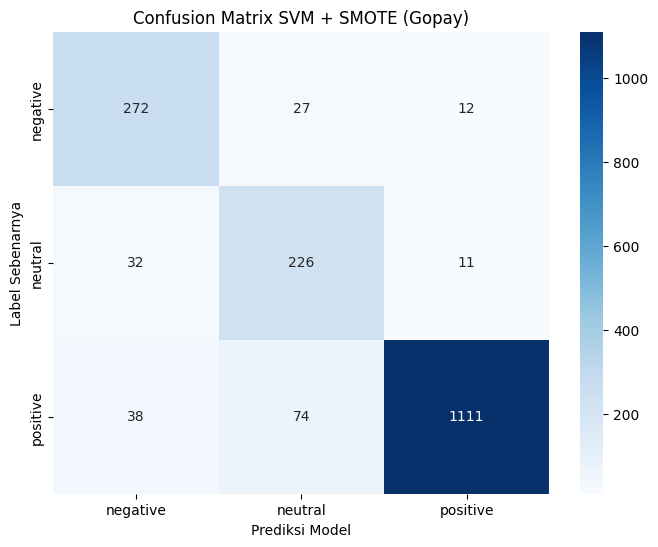

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# --- 1. IMPORT SMOTE ---
from imblearn.over_sampling import SMOTE

# --- 2. LOAD DATASET ---
# Menggunakan forward slash (/) agar aman di semua OS
file_path = "../../Pelabelan/PelabelanGopay/DatasetPelabelanGopay/Tahap5HasilPelabelan.csv"

try:
    data = pd.read_csv(file_path)
    print(f"[SUKSES] Data berhasil dimuat dari: {file_path}")
except FileNotFoundError:
    print(f"[ERROR] File tidak ditemukan di: {file_path}")
    print("Pastikan path file sudah benar.")
    exit()

# --- 3. PERSIAPAN DATA ---

# Perbaiki konsistensi nama kolom (gunakan 'label' kecil sesuai data Anda)
if 'steming_data' not in data.columns or 'label' not in data.columns:
    print("[ERROR] Kolom 'steming_data' atau 'label' tidak ditemukan.")
    print(f"Kolom yang tersedia: {list(data.columns)}")
    exit()

print(f"Jumlah data awal: {len(data)}")

# Konversi ke string & Bersihkan NaN
data['steming_data'] = data['steming_data'].astype(str)
data.dropna(subset=['steming_data', 'label'], inplace=True)

# Hapus data kosong
data = data[data['steming_data'].str.strip() != '']
data = data[data['steming_data'] != 'nan']

print(f"Jumlah data bersih: {len(data)}")

# Cek sebaran data SEBELUM SMOTE
print("\nSebaran Data Asli:")
print(data['label'].value_counts())

X_text = data['steming_data']
y = data['label']

# --- 4. EKSTRAKSI FITUR (TF-IDF) ---
print("\nMelakukan ekstraksi fitur TF-IDF...")
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(X_text)

# --- 5. SPLIT DATA ---
# Pisahkan Data Latih (Train) dan Uji (Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nData Training Asli: {X_train.shape[0]}")
print(f"Data Testing: {X_test.shape[0]}")

# --- 6. PENERAPAN SMOTE (HANYA PADA DATA LATIH) ---
print("\nMenerapkan SMOTE pada data training...")
# SMOTE akan membuat jumlah data Netral/Negatif sama banyaknya dengan Positif
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Cek hasil setelah SMOTE
print(f"Data Training setelah SMOTE: {X_train_resampled.shape[0]}")
print("Sebaran Data Training Baru (Seimbang):")
print(pd.Series(y_train_resampled).value_counts())

# --- 7. PELATIHAN MODEL SVM ---
print("\nMelatih Model SVM dengan data hasil SMOTE...")

# CATATAN: Karena data sudah seimbang berkat SMOTE, 
# kita TIDAK PERLU lagi pakai class_weight='balanced'.
svm_model = SVC(kernel='linear', random_state=42) 
svm_model.fit(X_train_resampled, y_train_resampled)

print("Pelatihan selesai!")

# --- 8. EVALUASI MODEL ---
# Prediksi tetap dilakukan ke data X_test yang MURNI (bukan hasil SMOTE)
y_pred = svm_model.predict(X_test)
akurasi = accuracy_score(y_test, y_pred)

print(f"\n--- HASIL EVALUASI (SVM + SMOTE - Gopay) ---")
print(f"Akurasi Model: {akurasi * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# --- 9. VISUALISASI ---
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=svm_model.classes_, 
            yticklabels=svm_model.classes_)
plt.title('Confusion Matrix SVM + SMOTE (Gopay)')
plt.ylabel('Label Sebenarnya')
plt.xlabel('Prediksi Model')
plt.show()

[SUKSES] Data berhasil dimuat dari: ../../Pelabelan/PelabelanGopay/DatasetPelabelanGopay/Tahap5HasilPelabelan.csv
Jumlah data awal: 9012
Jumlah data bersih: 9012

Sebaran Data Asli:
label
positive    6128
negative    1625
neutral     1259
Name: count, dtype: int64

Melakukan ekstraksi fitur TF-IDF...

Data Training Asli: 7209
Data Testing: 1803

Menerapkan SMOTE pada data training...
Data Training setelah SMOTE: 14715
Sebaran Data Training Baru (Seimbang):
label
positive    4905
neutral     4905
negative    4905
Name: count, dtype: int64

Melatih Model Naive Bayes dengan data SMOTE...
Pelatihan selesai!

--- HASIL EVALUASI (Naive Bayes + SMOTE) ---
Akurasi Model: 81.48%

Classification Report:
              precision    recall  f1-score   support

    negative       0.56      0.86      0.67       311
     neutral       0.73      0.64      0.68       269
    positive       0.95      0.84      0.89      1223

    accuracy                           0.81      1803
   macro avg       0.74  

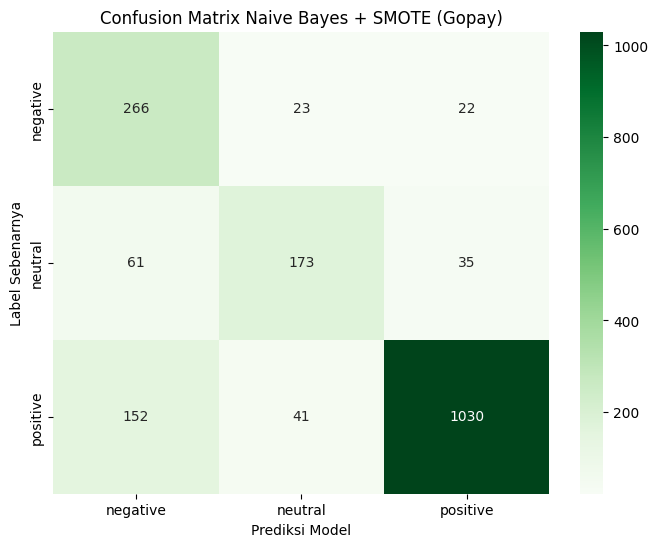

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# --- 1. IMPORT SMOTE ---
from imblearn.over_sampling import SMOTE

# --- 2. LOAD DATASET ---
# Menggunakan forward slash (/) agar aman
file_path = "../../Pelabelan/PelabelanGopay/DatasetPelabelanGopay/Tahap5HasilPelabelan.csv"

try:
    data = pd.read_csv(file_path)
    print(f"[SUKSES] Data berhasil dimuat dari: {file_path}")
except FileNotFoundError:
    print(f"[ERROR] File tidak ditemukan di: {file_path}")
    print("Pastikan path file sudah benar.")
    exit()

# --- 3. PERSIAPAN DATA ---

# Pengecekan kolom
if 'steming_data' not in data.columns or 'label' not in data.columns:
    print("[ERROR] Kolom 'steming_data' atau 'label' tidak ditemukan.")
    exit()

print(f"Jumlah data awal: {len(data)}")

# Konversi ke string & Bersihkan NaN
data['steming_data'] = data['steming_data'].astype(str)
data.dropna(subset=['steming_data', 'label'], inplace=True)
data = data[data['steming_data'].str.strip() != '']
data = data[data['steming_data'] != 'nan']

print(f"Jumlah data bersih: {len(data)}")

# Cek sebaran data SEBELUM SMOTE
print("\nSebaran Data Asli:")
print(data['label'].value_counts())

X_text = data['steming_data']
y = data['label']

# --- 4. EKSTRAKSI FITUR (TF-IDF) ---
print("\nMelakukan ekstraksi fitur TF-IDF...")
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(X_text)

# --- 5. SPLIT DATA ---
# Pisahkan Data Latih (Train) dan Uji (Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nData Training Asli: {X_train.shape[0]}")
print(f"Data Testing: {X_test.shape[0]}")

# --- 6. PENERAPAN SMOTE (HANYA PADA DATA LATIH) ---
print("\nMenerapkan SMOTE pada data training...")

# SMOTE menyeimbangkan jumlah data di X_train
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Cek hasil setelah SMOTE
print(f"Data Training setelah SMOTE: {X_train_resampled.shape[0]}")
print("Sebaran Data Training Baru (Seimbang):")
print(pd.Series(y_train_resampled).value_counts())

# --- 7. PELATIHAN MODEL NAIVE BAYES ---
print("\nMelatih Model Naive Bayes dengan data SMOTE...")

# Inisialisasi Naive Bayes
nb_model = MultinomialNB() 

# Latih menggunakan data hasil SMOTE
nb_model.fit(X_train_resampled, y_train_resampled)

print("Pelatihan selesai!")

# --- 8. EVALUASI MODEL ---
# Prediksi tetap menggunakan X_test yang ASLI (Murni)
y_pred = nb_model.predict(X_test)
akurasi = accuracy_score(y_test, y_pred)

print(f"\n--- HASIL EVALUASI (Naive Bayes + SMOTE) ---")
print(f"Akurasi Model: {akurasi * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# --- 9. VISUALISASI ---
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
# Gunakan warna Hijau (Greens) khas Naive Bayes
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=nb_model.classes_, 
            yticklabels=nb_model.classes_)
plt.title('Confusion Matrix Naive Bayes + SMOTE (Gopay)')
plt.ylabel('Label Sebenarnya')
plt.xlabel('Prediksi Model')
plt.show()